# Decision Trees

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

import Partitioner as part

# Fix the random seed for reproducibility
# !! Important !! : do not change this
seed = 1234
np.random.seed(seed)  

In [2]:
# Load dataset
X_tr, X_val, X_te, y_tr, y_val, y_te = part.getDefaultWineSets()

## Get Dataset Context

In [3]:
# Get Dataset Context
print(f"Number of samples: {X_tr.shape[0] + X_val.shape[0] + X_te.shape[0]}")
print(f"Features per sample: {X_tr.shape[1]}")

print(y_tr)

Number of samples: 6497
Features per sample: 12
[6 7 5 ... 6 5 5]


Training error: 0.46753913266615343
Validation error: 0.4784615384615385
Root feature index: 11
Root split threshold: 10.483333110809326


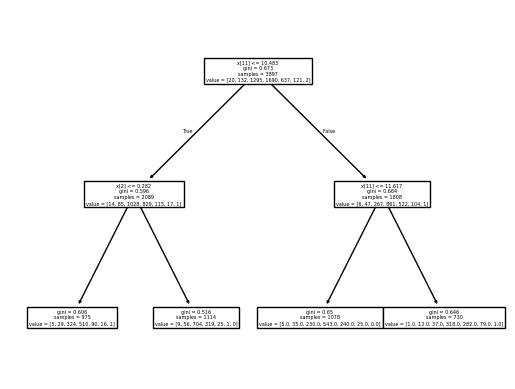

In [4]:
model = DecisionTreeClassifier(max_depth=2, random_state=seed)

model.fit(X_tr, y_tr)
err_tr = 1 - accuracy_score(y_tr, model.predict(X_tr))
err_val = 1 - accuracy_score(y_val, model.predict(X_val))

print(f"Training error: {err_tr}")
print(f"Validation error: {err_val}")

plot_tree(model)

print(f"Root feature index: {model.tree_.feature[0]}")
print(f"Root split threshold: {model.tree_.threshold[0]}")

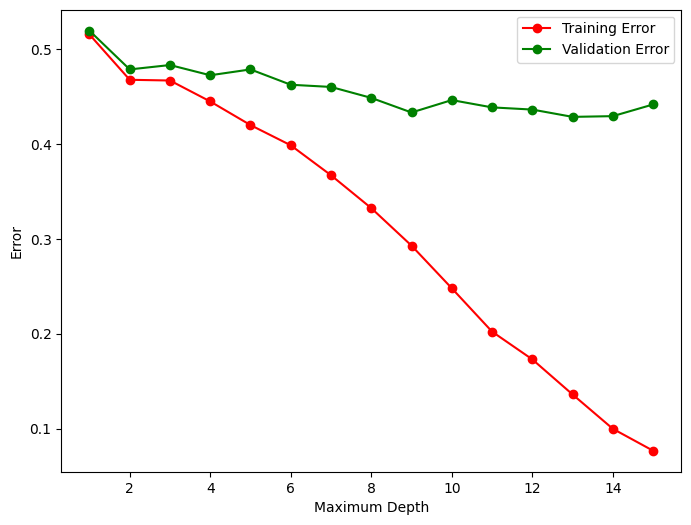

In [5]:
_, axes = plt.subplots(1, figsize=(8, 6))

max_depth = np.arange(1, 16, 1)
err_tr = np.zeros_like(max_depth, dtype=float)
err_val = np.zeros_like(max_depth, dtype=float)

for i, depth in enumerate(max_depth):
    model = DecisionTreeClassifier(max_depth=depth, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

axes.plot(max_depth, err_tr, marker='o', c='red', label="Training Error")
axes.plot(max_depth, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Maximum Depth")
axes.set_ylabel("Error")
axes.legend();

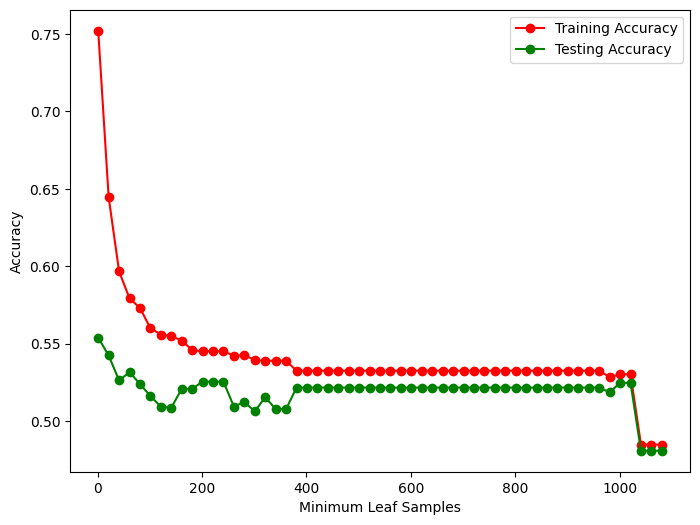

In [15]:
_, axes = plt.subplots(1, figsize=(8, 6))

min_samples_leaf = np.arange(1, 1101, 20)
err_tr = np.zeros_like(min_samples_leaf, dtype=float)
err_val = np.zeros_like(min_samples_leaf, dtype=float)

for i, min_samples in enumerate(min_samples_leaf):
    model = DecisionTreeClassifier(min_samples_leaf=min_samples, max_depth=10, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = accuracy_score(y_val, model.predict(X_val))

axes.plot(min_samples_leaf, err_tr, marker='o', c='red', label="Training Accuracy")
axes.plot(min_samples_leaf, err_val, marker='o', c='green', label="Testing Accuracy")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Accuracy")
axes.legend();